# CCO09: Notch

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scipy

In [2]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO09"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [19]:
samples = ["VO-C", "VO-G8", "VasHO-C", "VasHO-G8"]
batches = ["VO-C", "VO-G8", "VasHO-C", "VasHO-G8"]

# 1. Preprocess - done in CCO08

In [7]:
os.system(f"mkdir -p {WORK_DIR}/adata")

0

In [8]:
os.system(f"ln -s {WORK_DIR}/../CCO08/adata/new_data/raw {WORK_DIR}/adata")
os.system(f"ln -s {WORK_DIR}/../CCO08/adata/new_data/processed {WORK_DIR}/adata")

0

# 2. Cell type annotation

In [5]:
os.system(f"mkdir -p {WORK_DIR}/umap")
os.system(f"mkdir -p {WORK_DIR}/dotplot")
os.system(f"mkdir -p {WORK_DIR}/distribution")

0

## 2.1 label

In [5]:
os.system(f"mkdir -p {WORK_DIR}/adata/celltype_annotated")

0

In [6]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

In [7]:
group_names = ["ALL", "VO-C", "VO-G8", "VasHO-C", "VasHO-G8"]

celltypes_dict = {
    '0':  'PV', 
    '1':  'CM',
    '2':  'PV',
    '3':  'PV',
    '4':  'PV',
    '5':  'SM',
    '6':  'PV',
    '7':  'EC',
    '8':  'EC',
    '9':  'CM',
    '10': 'PV',
    '11': 'PV',
    '12': 'PV',
    '13': 'EP',
    '14': 'EP',
    '15': 'CM',
    '16': 'CM',
    '17': 'PV',
    '18': 'CM',
}

In [8]:
adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
adata.obs['cell_type'] = adata.obs['cell_type'].astype("category")

In [17]:
for batch in adata.obs["batch"].unique():
    adata_sub = adata[adata.obs["batch"] == batch]
    valid_cts = list(adata_sub.obs['cell_type'].value_counts().index[np.where(adata_sub.obs['cell_type'].value_counts() > 100)])
    adata_sub = adata_sub[adata_sub.obs['cell_type'].isin(valid_cts)]
    
    adata_sub.write(f"{WORK_DIR}/adata/celltype_annotated/{batch}.h5ad")

In [24]:
for i, batch in enumerate(batches):
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/celltype_annotated/{batch}.h5ad")
    if i == 0:
        adata_all = adata
    else:
        adata_all = sc.concat([adata_all, adata])
        
adata_all.write(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")

## 2.2 visualization

In [25]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


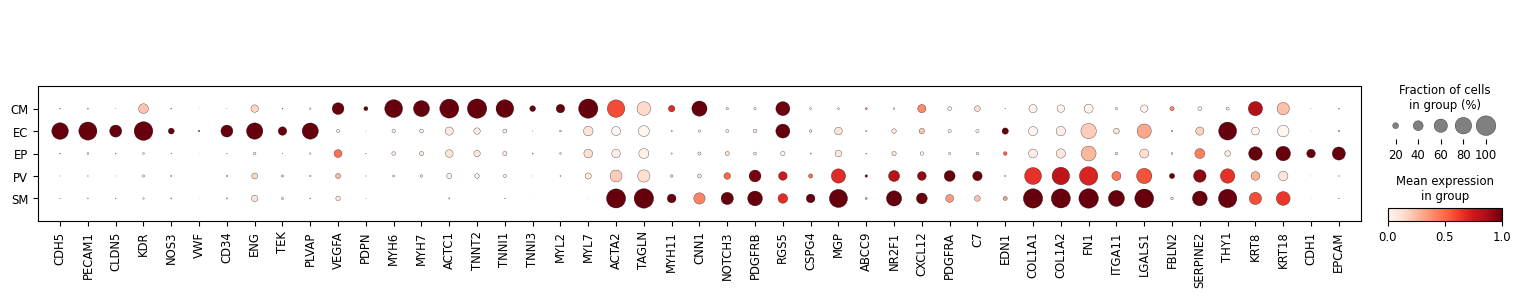

In [26]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

sc.pl.dotplot(adata, 
              marker_dict, 
              groupby="cell_type", 
              standard_scale="var", 
              show=False, 
             )
plt.savefig(f'{WORK_DIR}/dotplot/all.cell_type.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/all.cell_type.svg', bbox_inches="tight")
plt.show()

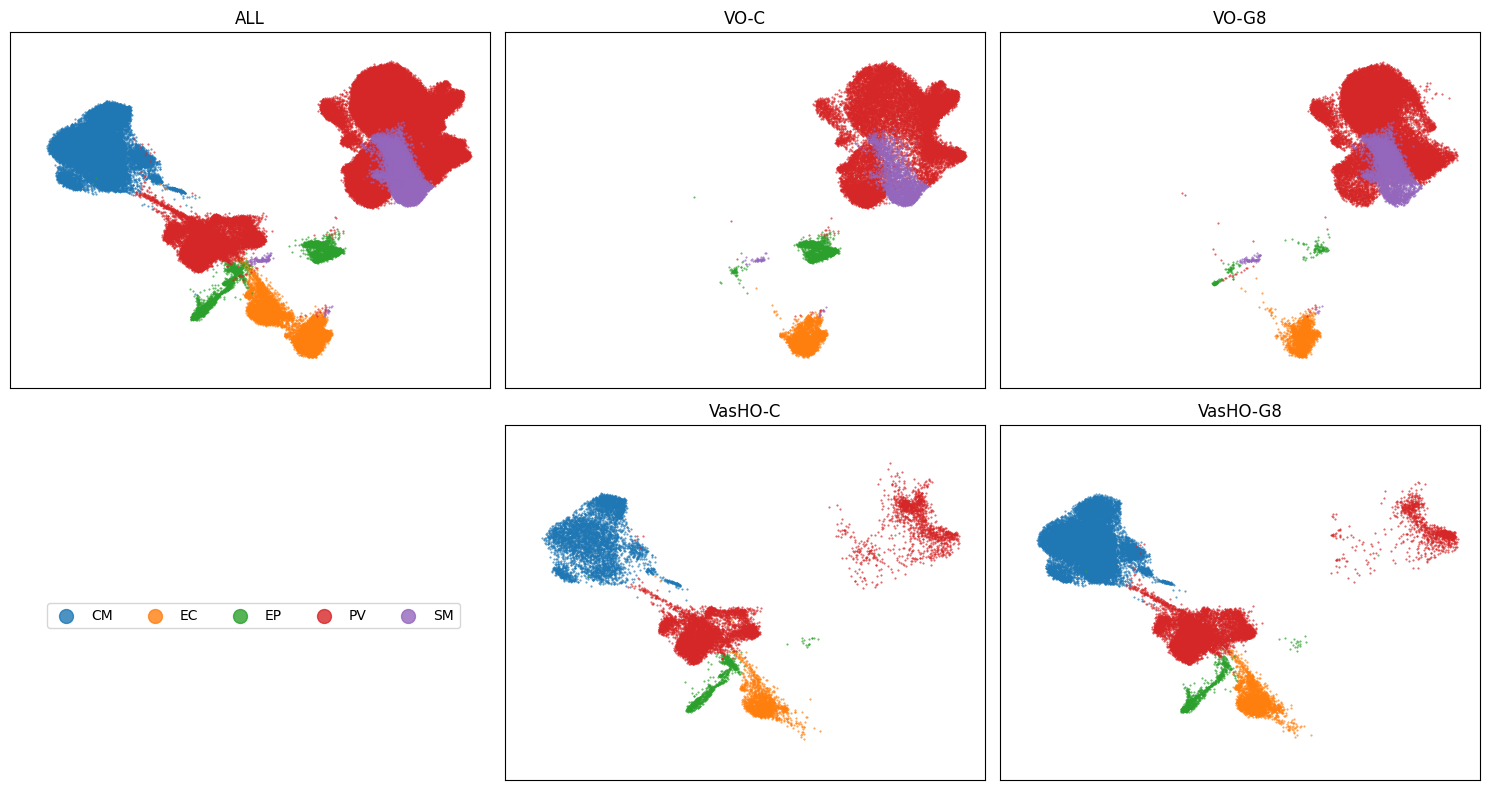

In [27]:
groups = ("ALL", "VO-C", "VO-G8", "VasHO-C", "VasHO-G8")

tab20_rgb = [(r, g, b, 0.8) for r, g, b in plt.cm.tab10.colors]

fig, axs = plt.subplots(2, 3, figsize=(15,8))
axs = axs.flatten()
axs_new = [axs[0], axs[1], axs[2], axs[4], axs[5]]
fig.delaxes(axs[3])

handles = []
labels = []


xmin = -9
xmax = 19
ymin = -8
ymax = 18

for i, group in enumerate(groups):
    ax = axs_new[i]
    if group == "ALL":
        adata_sub = adata
    else:
        adata_sub = adata[adata.obs["batch"] == group]

    for j, ct in enumerate(adata.obs["cell_type"].unique().sort_values()):
        sc_plot = ax.scatter(
            adata_sub[adata_sub.obs["cell_type"] == ct].obsm["X_umap"][:,0],
            adata_sub[adata_sub.obs["cell_type"] == ct].obsm["X_umap"][:,1],
            s=0.25,
            label=ct,
            color=tab20_rgb[j]
        )
        if i == 0:
            handles.append(sc_plot)
            labels.append(ct)
    
    ax.set_title(group)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, labels,
    loc='lower left',
    ncol=5,
    markerscale=20,
    bbox_to_anchor=(0.03, 0.2)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umap/all.cell_type.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umap/all.cell_type.svg', bbox_inches="tight")
plt.show()

In [28]:
# fig, axs = plt.subplots(1, 4, figsize=(12, 4))

# for i, batch in enumerate(adata.obs["batch"].unique().sort_values()):
#     adata_sub = adata[adata.obs["batch"] == batch]
#     ser = adata_sub.obs["cell_type"].value_counts().sort_index()
#     ser = ser / ser.sum()
#     ser.plot.bar(ax=axs[i])

# plt.tight_layout()
# plt.show()

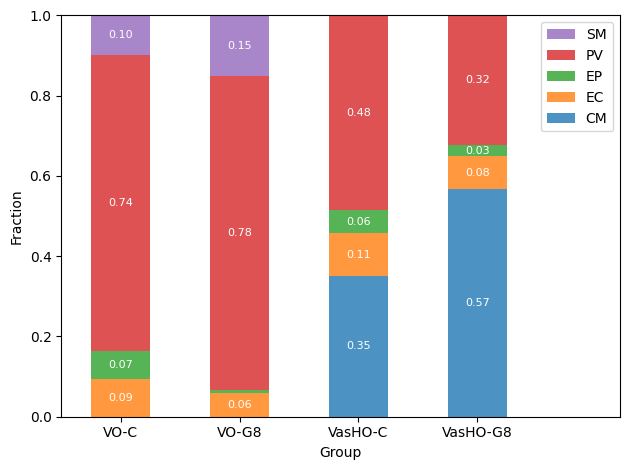

In [29]:
res = []
res_col = []

for j, sample in enumerate(groups):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type'].value_counts().sort_index())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[tab20_rgb[i] for i, col in enumerate(df.columns)])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
# plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/all.cell_type.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/all.cell_type.svg', bbox_inches="tight")
plt.show()

# 3. Label transfer

In [30]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD

In [32]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer")

0

## 3.1 EN

In [37]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer/EC")
# os.system(f"ln -s {PREV_DIR}/adata/HVCA/global_object_vasc_atlas_cxg.h5ad {WORK_DIR}/label_transfer/EC/")

0

In [38]:
adata_HVCA = sc.read_h5ad(f"{WORK_DIR}/label_transfer/EC/global_object_vasc_atlas_cxg.h5ad")
adata_HVCA_EN = adata_HVCA[adata_HVCA.obs["cell_type"] == "Endothelial cells"]

sc.pp.filter_cells(adata_HVCA_EN, min_genes=200)
sc.pp.filter_genes(adata_HVCA_EN, min_cells=3)
sc.pp.normalize_total(adata_HVCA_EN, target_sum=1e4)
sc.pp.log1p(adata_HVCA_EN)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


In [39]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")

In [40]:
adata_source = sc.pp.subsample(adata_HVCA_EN, n_obs=10000, random_state=42, copy=True)
adata_target = adata[adata.obs["cell_type"] == "EC"]

adata_target.obs["organ_uni"] = "Unknown"

/tmp/ipykernel_971018/4211055628.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_target.obs["organ_uni"] = "Unknown"


In [41]:
# Step 1: Align genes
common_genes = adata_source.var_names.intersection(adata_target.var_names)
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

# Step 2: Concatenate for shared processing
adata_combined = ad.concat([adata_source, adata_target], label="dataset", keys=["source", "target"])

# Step 4: Dimensionality reduction (PCA)
n_pcs = 50  # can adjust based on dataset size
svd = TruncatedSVD(n_components=n_pcs)
X_pca = svd.fit_transform(adata_combined.X)

# Step 5: Split PCA embeddings
source_mask = adata_combined.obs["dataset"] == "source"
target_mask = ~source_mask

X_source = X_pca[source_mask]
X_target = X_pca[target_mask]

y_source = adata_combined.obs.loc[source_mask, "organ_uni"]

# Step 6: Train classifier on source labels
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_source, y_source)

# Step 7: Predict labels for target
predicted_labels = knn.predict(X_target)

# Step 8: Add predictions back to target AnnData
adata_target.obs["organ_uni_pred"] = predicted_labels

In [45]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_target[adata_target.obs['batch'] == sample]
        res.append(adata_sample.obs['organ_uni_pred'].value_counts())
        res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

df.to_csv(f"{WORK_DIR}/label_transfer/EC/pred.csv")

cols_to_keep = df.columns[np.where(np.max(df > 0.11, axis=0))[0]].to_list()
df['others'] = df.drop(columns=cols_to_keep).sum(axis=1)
cols_to_keep.append('others')
df = df[cols_to_keep]

df.to_csv(f"{WORK_DIR}/label_transfer/EC/pred.partial.csv")

In [46]:
df = pd.read_csv(f"{WORK_DIR}/label_transfer/EC/pred.partial.csv", index_col=0)
df

,heart,lung,small_intestine,uterus,others
VO-C,0.321295,0.081777,0.207970,0.205895,0.183064
VO-G8,0.379292,0.129952,0.163233,0.155837,0.171685
VasHO-C,0.115213,0.373647,0.062381,0.227244,0.221515
VasHO-G8,0.161629,0.181360,0.028967,0.407221,0.220823


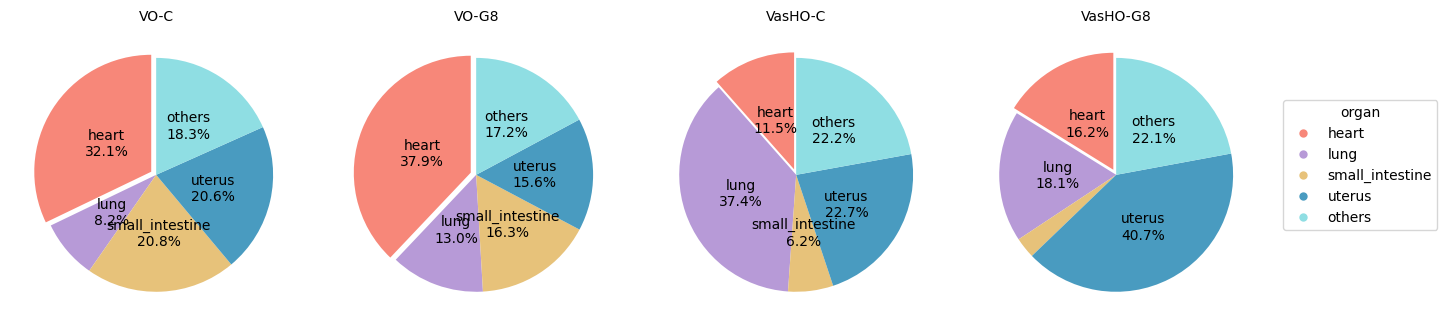

In [47]:
# --- CONFIG ---
min_pct_to_label = 5.0   # show label + leader line only if >= this %
outer_label_offset = 0.5  # how far outside labels sit
donut_width = 1         # 0 for full pie, >0 for donut
colors = {"heart": "#F78779", "uterus": "#499BC0", "lung": "#B79AD7", "small_intestine": "#E7C27A", "others": "#8FDEE3"}
explode = [0.05, 0, 0, 0, 0]

# unified color map for organs (columns)
df = pd.read_csv(f"{WORK_DIR}/label_transfer/EC/pred.partial.csv", index_col=0)
organs = list(df.columns)

# layout
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (group, row) in zip(axes, df.iterrows()):
    vals = row.values.astype(float)
    total = vals.sum()
    colseq = [colors[o] for o in organs]

    # draw pie/donut
    wedges, _ = ax.pie(
        vals,
        startangle=90,
        labels=None,                   # no on-slice labels
        colors=colseq,
        wedgeprops=dict(width=donut_width) if donut_width > 0 else None,
        explode=explode
    )

    # label only larger slices, outside with leader lines
    if total > 0:
        for w, v, label in zip(wedges, vals, organs):
            pct = 100.0 * v / total
            if pct >= min_pct_to_label:
                ang = 0.5 * (w.theta2 + w.theta1)
                ang_rad = np.deg2rad(ang)
                x, y = np.cos(ang_rad), np.sin(ang_rad)
                ax.annotate(
                    f'{label}\n{pct:.1f}%',
                    xy=(x, y),
                    xytext=(outer_label_offset * x, outer_label_offset * y),
                    ha='center', va='center',
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', lw=0)
                )

    ax.set_title(str(group), fontsize=10)
    ax.set_aspect('equal')

# single unified legend (outside)
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=colors[o], markeredgecolor='none', label=o)
    for o in organs
]
fig.legend(handles=legend_handles, title='organ', loc='center left', bbox_to_anchor=(1.0, 0.5))
# fig.suptitle("Organ of EC predicted through PCA-based transfer learning", y=1.03)

# save/show
plt.savefig(f"{WORK_DIR}/label_transfer/EC/tl.pca.pie.png", bbox_inches='tight')
plt.savefig(f"{WORK_DIR}/label_transfer/EC/tl.pca.pie.svg", bbox_inches='tight')
plt.show()

# 4. DE

In [48]:
cell_types = list(adata.obs["cell_type"].unique())

os.system(f"rm -r {WORK_DIR}/volcano/*")

for ct in cell_types:
    os.system(f"mkdir -p {WORK_DIR}/volcano/{ct}")

In [49]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

In [50]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")

In [51]:
list(adata_sub.obs["batch"].value_counts().index[np.where(adata_sub.obs["batch"].value_counts() > 100)].sort_values())

['VasHO-G8']

In [52]:
for ct in cell_types:
    for lbl_type in ["batch"]:

        adata_sub = adata[adata.obs['cell_type'] == ct]
        all_lbls = list(adata_sub.obs[lbl_type].value_counts().index[np.where(adata_sub.obs[lbl_type].value_counts() > 100)].sort_values())

        if len(all_lbls) < 2:
            continue
        
        for i in range(0, len(all_lbls)):
            for j in range(i+1, len(all_lbls)):
                lbl1 = all_lbls[i]
                lbl2 = all_lbls[j]
                volcano_plot2(adata_sub, 
                              lbl1, 
                              lbl2, 
                              f"{ct}.{lbl1}.{lbl2}.png", 
                              keygenes=None, 
                              label_type=lbl_type,
                              fc_thres=1,
                              save=f"{WORK_DIR}/volcano/{ct}/{ct}.{lbl1}.{lbl2}.png", 
                              save_tsv=f"{WORK_DIR}/volcano/{ct}/{ct}.{lbl1}.{lbl2}.tsv"
                             )

/tmp/ipykernel_971018/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_971018/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_971018/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_971018/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.tte

# 5. CPDB

In [1]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [2]:
base_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO09"

cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
work_dir  = f"{base_dir}/cpdb"
data_dir  = f"{base_dir}/cpdb/adata"
processed_dir = f"{base_dir}/cpdb/processed"
figs_dir = f"{base_dir}/cpdb/figs"

In [3]:
os.system(f"mkdir -p {data_dir}")
os.system(f"mkdir -p {processed_dir}")

0

In [4]:
adata_full = sc.read_h5ad(f"{base_dir}/adata/celltype_annotated/ALL.h5ad")
    
sc.pp.highly_variable_genes(adata_full, n_top_genes=4000)

for batch in adata_full.obs["batch"].unique():
    adata_full[adata_full.obs['batch'] == batch].write(f"{work_dir}/adata/{batch}.h5ad")

In [5]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob.glob(pattern):
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    for cpdb_group_id in ("cell_type", ):
        os.system(f"mkdir -p {work_dir}/{cpdb_group_id}")
        
        metadata_df = pd.DataFrame({
            "barcode_sample" : adata.obs_names,
            "cell_type"      : adata.obs[cpdb_group_id].to_list()
        })

        metadata_df.index = np.arange(metadata_df.shape[0])
        metadata_path     = f"{work_dir}/{cpdb_group_id}/{label}.statistical.metadata.tsv"
        metadata_df.to_csv(metadata_path,index=False,sep="\t")
        out_dir      = f"{work_dir}/{cpdb_group_id}/{label}.statistical"

        # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
        cpdb_results = cpdb_statistical_analysis_method.call(
            cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
            meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
            counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
            counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
            score_interactions = True,              # optional: whether to score interactions or not. 
            output_path        = out_dir,           # Path to save results
            pvalue             = 0.05
        )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/adata/VO-C.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/processed/VO-C.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VO-C.statistical.metadata.tsv
[ ][CORE][13/03/26-03:22:40][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][13/03/26-03:22:42][INFO] Running Real Analysis
[ ][CORE][13/03/26-03:22:42][INFO] Running Statistical Analysis


100%|███████████████████████████████████████| 1000/1000 [00:49<00:00, 20.22it/s]


[ ][CORE][13/03/26-03:23:32][INFO] Building Pvalues result
[ ][CORE][13/03/26-03:23:32][INFO] Building results
[ ][CORE][13/03/26-03:23:32][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 39.55it/s]

[ ][CORE][13/03/26-03:23:32][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


...

[ ][CORE][13/03/26-03:26:03][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 120.85it/s]


[ ][CORE][13/03/26-03:26:03][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████████████████████████████████████| 16/16 [00:00<00:00, 114.81it/s]

Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_analysis_deconvoluted_03_13_2026_032603.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_analysis_deconvoluted_percents_03_13_2026_032603.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_analysis_means_03_13_2026_032603.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_analysis_pvalues_03_13_2026_032603.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_analysis_significant_means_03_13_2026_032603.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical/statistical_an

In [6]:
for cpdb_group_id in ("cell_type", ):
    
    pattern = os.path.join(work_dir, cpdb_group_id, "*.statistical")
    date = "03_13_2026"
    for cpdb_dir in glob.glob(pattern):
        label = os.path.basename(cpdb_dir).replace(".statistical","")
        means_path         = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_means_{date}_*.txt"))[0]
        pvals_path         = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_pvalues_{date}_*.txt"))[0]
        deconvolution_path = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
        interaction_path   = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

        means_df         = pd.read_csv(means_path,sep="\t")
        pvals_df         = pd.read_csv(pvals_path,sep="\t")
        deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
        interaction_df   = pd.read_csv(interaction_path,sep="\t")

        adata_path = os.path.join(data_dir,f"{label}.h5ad")
        adata      = ad.read_h5ad(adata_path)
        adata.obs["cpdb_key"] = adata.obs[cpdb_group_id]
        # adata.obs["cpdb_key"] = adata.obs["cell_type"]

        for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
            df = kpy.plot_cpdb(
                adata=adata,
                cell_type1=cpdb_key,
                cell_type2=".",
                means=means_df,
                pvals=pvals_df,
                celltype_key="cpdb_key",
                highlight_size=1,
                figsize=(24,24),
                title=f"{label} {cpdb_key}",
                default_style=False,
                return_table=True
            )
            df.index = [index.replace(">@<","-") for index in df.index]
            df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
            df["significant"] = df["significant"].fillna("no")
            df_path = os.path.join(cpdb_dir, f"{label}__{cpdb_key}.csv")
            df.to_csv(df_path)

VasHO-C: 100%|████████████████████████████████████| 4/4 [00:00<00:00, 10.35it/s]


In [7]:
from plotnine import scale_color_identity, scale_fill_identity
from plotnine import scale_color_manual

for cpdb_group_id in ("cell_type", ):
    os.system(f"mkdir -p {work_dir}/{cpdb_group_id}/fig")
    
    pattern = os.path.join(work_dir, cpdb_group_id, "*.statistical")
    for cpdb_dir in glob.glob(pattern):
        print(cpdb_dir)
        label = os.path.basename(cpdb_dir).replace(".statistical","")
        means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
        pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
        decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
        adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

        out = kpy.plot_cpdb_heatmap(
            pvals=pvals_df,
            symmetrical=False,
            return_tables=True
        )

        g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
        g.ax_col_dendrogram.remove()
        g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
        fig_path = f"{work_dir}/{cpdb_group_id}/fig/{label}.n_signif_interactions_heatmap.png"
        plt.savefig(fig_path,dpi=100)
        plt.close()

        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=".",
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key=cpdb_group_id,
            highlight_size=1,
            figsize=(6,6),
            title=f"{label}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df = df[df["significant"] == "yes"]
        df_path = f"{work_dir}/{cpdb_group_id}/fig/{label}.csv"
        df.to_csv(df_path)

        p = kpy.plot_cpdb(
            adata=adata,
            cell_type1=".",
            cell_type2=".",
            keep_significant_only=True,
            means=means_df,
            pvals=pvals_df,
            celltype_key=cpdb_group_id,
            figsize=(20, 8),
            title=f"{label}: active interactions",
            return_table=False
        )
        p.save(f"{work_dir}/{cpdb_group_id}/fig/{label}.dotplot.png")

        cts = adata.obs[cpdb_group_id].unique().to_list()
        # if np.nan in cts:
        #     cts.remove(np.nan)

        sector_colors = {
            "CM": (60/255, 170/255, 60/255),
            "EC": (230/255, 80/255, 160/255),
            "EP": (60/255, 180/255, 220/255),
            "PR": (255/255, 235/255, 125/255),
            "FB": (240/255, 180/255, 20/255),
            "SM": (220/255, 160/255, 30/255),
            "UN": (190/255, 190/255, 190/255),
            "OTH": (170/255, 170/255, 170/255),
        }

        p = kpy.plot_cpdb_chord(
            adata=adata[adata.obs[cpdb_group_id] != "UN"],
            cell_type1='.',
            cell_type2='.',
            keep_celltypes=cts,
            means=means_df,
            pvals=pvals_df,
            deconvoluted=decon_df,
            celltype_key=cpdb_group_id,
            link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
            sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
            legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
            link_offset=1,
            sector_colors=sector_colors
        )

        plt.savefig(f"{work_dir}/{cpdb_group_id}/fig/{label}.chordplot.png")
        plt.close()

#         if label not in ["VO", "CA"]:
#             p = kpy.plot_cpdb_chord(
#                 adata=adata[adata.obs[cpdb_group_id] != "UN"],
#                 cell_type1='EC',
#                 cell_type2='CM',
#                 keep_celltypes=cts,
#                 means=means_df,
#                 pvals=pvals_df,
#                 deconvoluted=decon_df,
#                 celltype_key=cpdb_group_id,
#                 link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
#                 sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
#                 legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
#                 # legend_kwargs={},
#                 link_offset=1,
#                 sector_colors=sector_colors
#             )

#             plt.savefig(f"{figs_dir}/{label}.chordplot.EC_CM.png")
#             plt.close()

#         if True:
#             p = kpy.plot_cpdb_chord(
#                 adata=adata[adata.obs[cpdb_group_id] != "UN"],
#                 cell_type1='.',
#                 cell_type2='.',
#                 keep_celltypes=cts,
#                 means=means_df,
#                 pvals=pvals_df,
#                 deconvoluted=decon_df,
#                 celltype_key=cpdb_group_id,
#                 interaction=["VEGFA"],
#                 link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
#                 sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
#                 legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 10},
#                 link_offset=1,
#                 sector_colors=sector_colors
#             )

#             plt.savefig(f"{figs_dir}/{label}.chordplot.VEGFA.png")
#             plt.close()

/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VO-C.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VO-G8.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-G8.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO09/cpdb/cell_type/VasHO-C.statistical
